In [1]:
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt


file_path = 'Full_features.csv'
dataset = pd.read_csv(file_path)

X = dataset[['Feature1', 'Feature2']].values
y = dataset['Label'].values

y_encoded = to_categorical(y - 1, num_classes=3)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = Sequential([
    Dense(16, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(16, activation='relu'),
    Dense(3, activation='softmax')  # Multi-class output with softmax activation
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


history = model.fit(X_train_scaled, y_train, epochs=50, batch_size=16, validation_split=0.2, verbose=1)

test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)

print(f"Test Accuracy: {test_accuracy:.2f}")


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.3088 - loss: 1.3024 - val_accuracy: 0.2292 - val_loss: 1.1990
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2277 - loss: 1.1756 - val_accuracy: 0.3958 - val_loss: 1.1139
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3066 - loss: 1.1022 - val_accuracy: 0.3542 - val_loss: 1.0414
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3667 - loss: 1.0201 - val_accuracy: 0.6250 - val_loss: 0.9717
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6550 - loss: 0.9478 - val_accuracy: 0.6250 - val_loss: 0.8997
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6287 - loss: 0.8751 - val_accuracy: 0.6250 - val_loss: 0.8288
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6450 - loss: 0.7898 - val_accuracy: 0.6250 - val_loss: 0.7622
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6646 - loss: 0.7133 - val_accuracy: 0.6250 - val_loss

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3903 - loss: 238.3573
Test Accuracy: 0.37


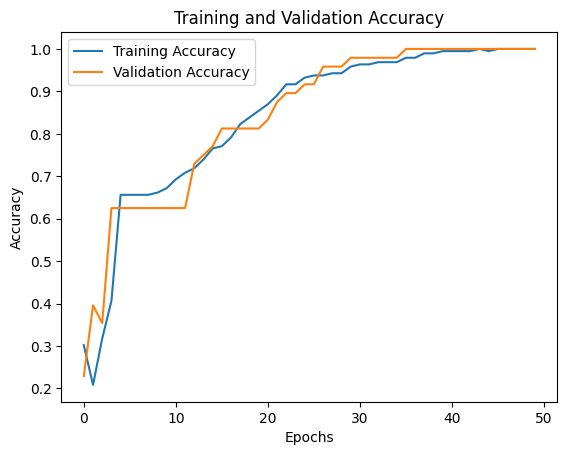

In [2]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy:.2f}")

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

In [3]:

test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy:.2f}")


predictions = model.predict(X_test_scaled)


predicted_classes = predictions.argmax(axis=1)


true_classes = y_test.argmax(axis=1)


for i in range(5):
    print(f"Sample {i+1}: True Label = {true_classes[i]}, Predicted Label = {predicted_classes[i]}")

new_input = [[1.9, 200]]
new_input_scaled = scaler.transform(new_input)
new_prediction = model.predict(new_input_scaled)
new_predicted_class = new_prediction.argmax(axis=1)[0]
print(f"New Input: {new_input}")
print(f"Predicted Class: {new_predicted_class}")




Test Accuracy: 1.00
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
Sample 1: True Label = 2, Predicted Label = 2
Sample 2: True Label = 2, Predicted Label = 2
Sample 3: True Label = 1, Predicted Label = 1
Sample 4: True Label = 0, Predicted Label = 0
Sample 5: True Label = 2, Predicted Label = 2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
New Input: [[1.9, 200]]
Predicted Class: 0


In [5]:
import numpy as np
SAVED_MODEL_FILENAME = "saved_model.keras"
model.save(SAVED_MODEL_FILENAME)

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()
tflite_model_path = "model.tflite"
with open(tflite_model_path, "wb") as f:
    f.write(tflite_model)

print(f"TFLite model saved at: {tflite_model_path}")

converter.optimizations = [tf.lite.Optimize.DEFAULT]

def representative_dataset():
    for data in X_train:
        yield [data.astype(np.float32)]

converter.representative_dataset = representative_dataset

converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_quant_model = converter.convert()

tflite_quant_model_path = "model_quant.tflite"
with open(tflite_quant_model_path, "wb") as f:
    f.write(tflite_quant_model)

print(f"Quantized TFLite model saved at: {tflite_quant_model_path}")



Saved artifact at '/tmp/tmpw_7xgyee'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 2), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  139266719607696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139266626566656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139266626565424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139266626562432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139266626567008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139266626567712: TensorSpec(shape=(), dtype=tf.resource, name=None)
TFLite model saved at: model.tflite
Saved artifact at '/tmp/tmpfj_vd84c'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 2), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captur

/usr/local/lib/python3.10/dist-packages/tensorflow/lite/python/convert.py:983: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Quantized TFLite model saved at: model_quant.tflite


In [6]:
!xxd -i model.tflite > model.cc
!xxd -i model_quant.tflite > model_quant.cc

In [7]:
predict_dataset = tf.convert_to_tensor([
    [2.0, 151],
    [5.8, 450],
    [3.1, 231]
])

print(predict_dataset)
dataset = scaler.transform(predict_dataset)
print(dataset)
new = model.predict(dataset)
new_test = new.argmax(axis=1)
print(new_test)

tf.Tensor(
[[  2.  151. ]
 [  5.8 450. ]
 [  3.1 231. ]], shape=(3, 2), dtype=float32)
[[-0.73545956 -1.04876716]
 [ 1.19440436  0.66039054]
 [-0.17681482 -0.59146744]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
[0 2 1]


In [8]:
means = X_train.mean(axis=0)
stds = X_train.std(axis=0)
print(means)
print(stds)

[  3.44815727 334.4712977 ]
[  1.96905085 174.93997144]
